# Confusion Matrix Notebook

In this notebook we will create a confusion matrix for the behavioral responses across our glint experiment, for humans and models. 

Essentially we will create 18 x 18 matrix (familiar) and 4 x 4 matrix (novel), Each value in said matrix will correspond to the amount of times say someone gave the response cat for a cat target trial, dog trial, and so one so forth. This way we can see what are the responses participants give for each target object class.

Of importance, you will need to exclude participants that we excluded during regular preprocessing.

Questions amd predictions:

How Does the response pattern of humans compare to models?

Natural: Models and Humans should align relatively similar

Feature: Models and Humans should align relatively similar

Shape: Models and Humans should display a high degree of dissimilarity 

Models prioritize and use features, whilst humans can use both shape and features. Therefore, we should see that models and humans display a high degree of similarity on the feature conditions whilst displaying a high degree of dissimilarity on the shape condition. 

# Adult Confusion Matrix

### Import packages

In [3]:
# Import Necessary Packages 
import os
import pandas as pd
import glob
import numpy as np
import pdb

### Function 1: create_summary_dataframe

To run this notebook properly, just run each of these functions in their order. For demonstration, we will use the familiar experiment and complete each step using familiar glint

In [2]:
'''
This function goes through adult behavioral experiments (novel and familiar) and produces two summary dataframes for each experiment
and applies the exclusion criteria to the data for each participant before we create the summary dataframes.
Exclusion criteria 1: Remove No responses
Exclusion criteria 2: Remove RTs less than or equal to 100ms
Exclusion criteria 3: Remove RTs outside mean ± 2*SD
'''

import glob
import pandas as pd

experiments = ['familiar', 'novel'] # set experiment variable to either 'familiar' or 'novel', this will determine which data files we pull and how we structure the summary dataframes

def create_summary_dataframe(experiments):

    # Loop through each experiment version (familiar and novel)
    for experiment in experiments:

        # Define the paths 
        base = '/zpool/vladlab/data_drive/glint_master/data/adult_data' # set base path to the adult data folder
            
        core_path = f'{base}/{experiment}_glint' # set core path using experiment variable and base path

        # if statement to set the list of excluded participants and objects based on which experiment version we are analyzing (familiar or novel)
        if experiment == 'familiar':
            excluded_participants = ['66afcaa60f7d8f58dc21db8e', '66cec5a3fdf1fe2c010e9971']
            objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
        elif experiment == 'novel':
            excluded_participants = ['66a398080da27efcc3e8ecef', '670efd496f9f47e38a4b1d7d', '5aed18cf026e1300018199b3']
            objects = ['krar', 'sarangi', 'sistrum', 'sheng']

        # Initialize empty dataframe
        participant_summary_df = pd.DataFrame()

        sub_summary = pd.DataFrame()
            
        # import the files
        files = glob.glob(f'{core_path}/*.csv') 
        print(f"You have selected {experiment} glint experiment")

        # loop through each object
        for file in files:

            for obj in objects:

                # Take the data for one participant at a time
                data = pd.read_csv(file)

                # Check if the participant is in the excluded list
                if data.loc[0, 'participant'] in excluded_participants:
                    continue # skip this participant if they are in the excluded list
                
                '''        
                We apply the exclusion criteria to the data for each participant before we create the summary dataframes.
                Exclusion criteria 1: Remove No responses
                Exclusion criteria 2: Remove RTs less than or equal to 100ms
                Exclusion criteria 3: Remove RTs outside mean ± 2*SD
                
                '''
                # Exclusion criteria 1: Remove No responses
                data_exclusion_1 = data[data['response_label'] != 'no_response']

                # Exclusion criteria 2: Remove RTs less than or equal to 100ms
                data_exclusion_2 = data_exclusion_1[data_exclusion_1['key_resp.rt'] >= 0.1]

                # Exclusion criteria 3: Remove RTs outside mean ± 2*SD
                rt_mean = data_exclusion_2['key_resp.rt'].mean()
                rt_std = data_exclusion_2['key_resp.rt'].std()
                data_exclusion_3 = data_exclusion_2[(data_exclusion_2['key_resp.rt'] >= rt_mean - 2*rt_std) & (data_exclusion_2['key_resp.rt'] <= rt_mean + 2*rt_std)]

                # Filter for the current object class
                if experiment == 'familiar':
                    object_trials = data_exclusion_3[data_exclusion_3['object_class'] == obj]
                
                elif experiment == 'novel':
                    object_trials = data_exclusion_3[data_exclusion_3['img_class'] == obj]
                
                # Extract only the columns you want
                if experiment == 'familiar':
                    subset = object_trials[[
                        'participant',
                        'img_condition', # condition (natural, scrambled, line_drawing)
                        'object_class', # The correct object class of the image they were shown (ex: airplane, car, etc.)
                        'object_category', # The animacy category of the image they were shown (animate, inanimate natural, inanimate artificial)
                        'response_label', # Response given by subject (ex: car, dog, cat, etc.)
                        'response_animacy', # Animacy of the response they gave (animate, inanimate natural, inanimate artificial)
                        'key_resp.corr', # Whether the response was correct (1) or incorrect (0)
                        'key_resp.keys', # The actual key they pressed for their response
                        'prompt_1', # The first prompt they saw for that trial (ex: "Is this a car?")
                        'prompt_2', 
                        'prompt_3', 
                        'prompt_4', 
                        'prompt_5', 
                        'prompt_6', 
                        'prompt_7', 
                        'prompt_8', 
                        'prompt_9']].copy()

                # if experiment is novel, we only want to keep the columns that are relevant to the novel experiment    
                if experiment == 'novel':
                    subset = object_trials[[
                        'participant',
                        'condition',
                        'img_class',
                        'response_label', 
                        'key_resp.corr', 
                        'key_resp.keys', 
                        'prompt_1',
                        'prompt_2',
                        'prompt_3',
                        'prompt_4']].copy()
                
                # Rename the columns to standardize across experiment versions
                column_map = {
                    "response_label": "prediction",
                    "key_resp.corr": "correct (0=incorrect, 1=correct)",
                    "key_resp.keys": "keyboard_response",
                    "img_condition": "condition_block",
                    "object_category": "correct_animacy",
                    "img_class": "obj_true_class",
                    "object_class": "obj_true_class",
                    "condition": "condition_block"}

                #rename the columns to standardize across experiment versions
                data = subset.rename(columns=column_map)

                # Append to the summary list
                participant_summary_df = pd.concat([participant_summary_df, data], ignore_index=True) #append the subset dataframe for this object class and participant to the overall participant summary dataframe

            # Combine all into one dataframe
            if experiment == 'familiar':
                familiar_sub_summary = pd.concat([sub_summary, participant_summary_df], ignore_index=True)
            
            elif experiment == 'novel':
                novel_sub_summary = pd.concat([sub_summary, participant_summary_df], ignore_index=True)

    return familiar_sub_summary, novel_sub_summary

familiar_sub_summary, novel_sub_summary = create_summary_dataframe(experiments)


You have selected familiar glint experiment
You have selected novel glint experiment


### Function 2: create_confusion_matrices

Experiment: Familiar, Condition: natural
natural
prediction      airplane  apple  avocado   bear  binoculars  bread  butterfly  \
obj_true_class                                                                  
airplane           96.41   0.00     0.51   0.00        0.51   0.00       1.03   
apple               0.00  97.41     0.52   0.00        0.52   0.00       0.52   
avocado             0.00   0.00    96.92   0.00        0.00   0.51       0.00   
bear                0.00   0.00     0.00  96.92        0.00   0.00       0.00   
binoculars          0.51   0.00     0.00   0.00       97.97   0.00       0.00   
bread               0.53   0.00     0.00   0.00        0.00  96.30       0.53   
butterfly           0.00   0.00     0.00   0.51        0.00   0.00      96.45   
car                 0.00   0.00     0.00   0.00        0.00   0.00       0.00   
cat                 0.00   0.00     0.00   0.00        0.00   0.00       0.00   
corn                0.00   0.00     0.00   0.00        0.00 

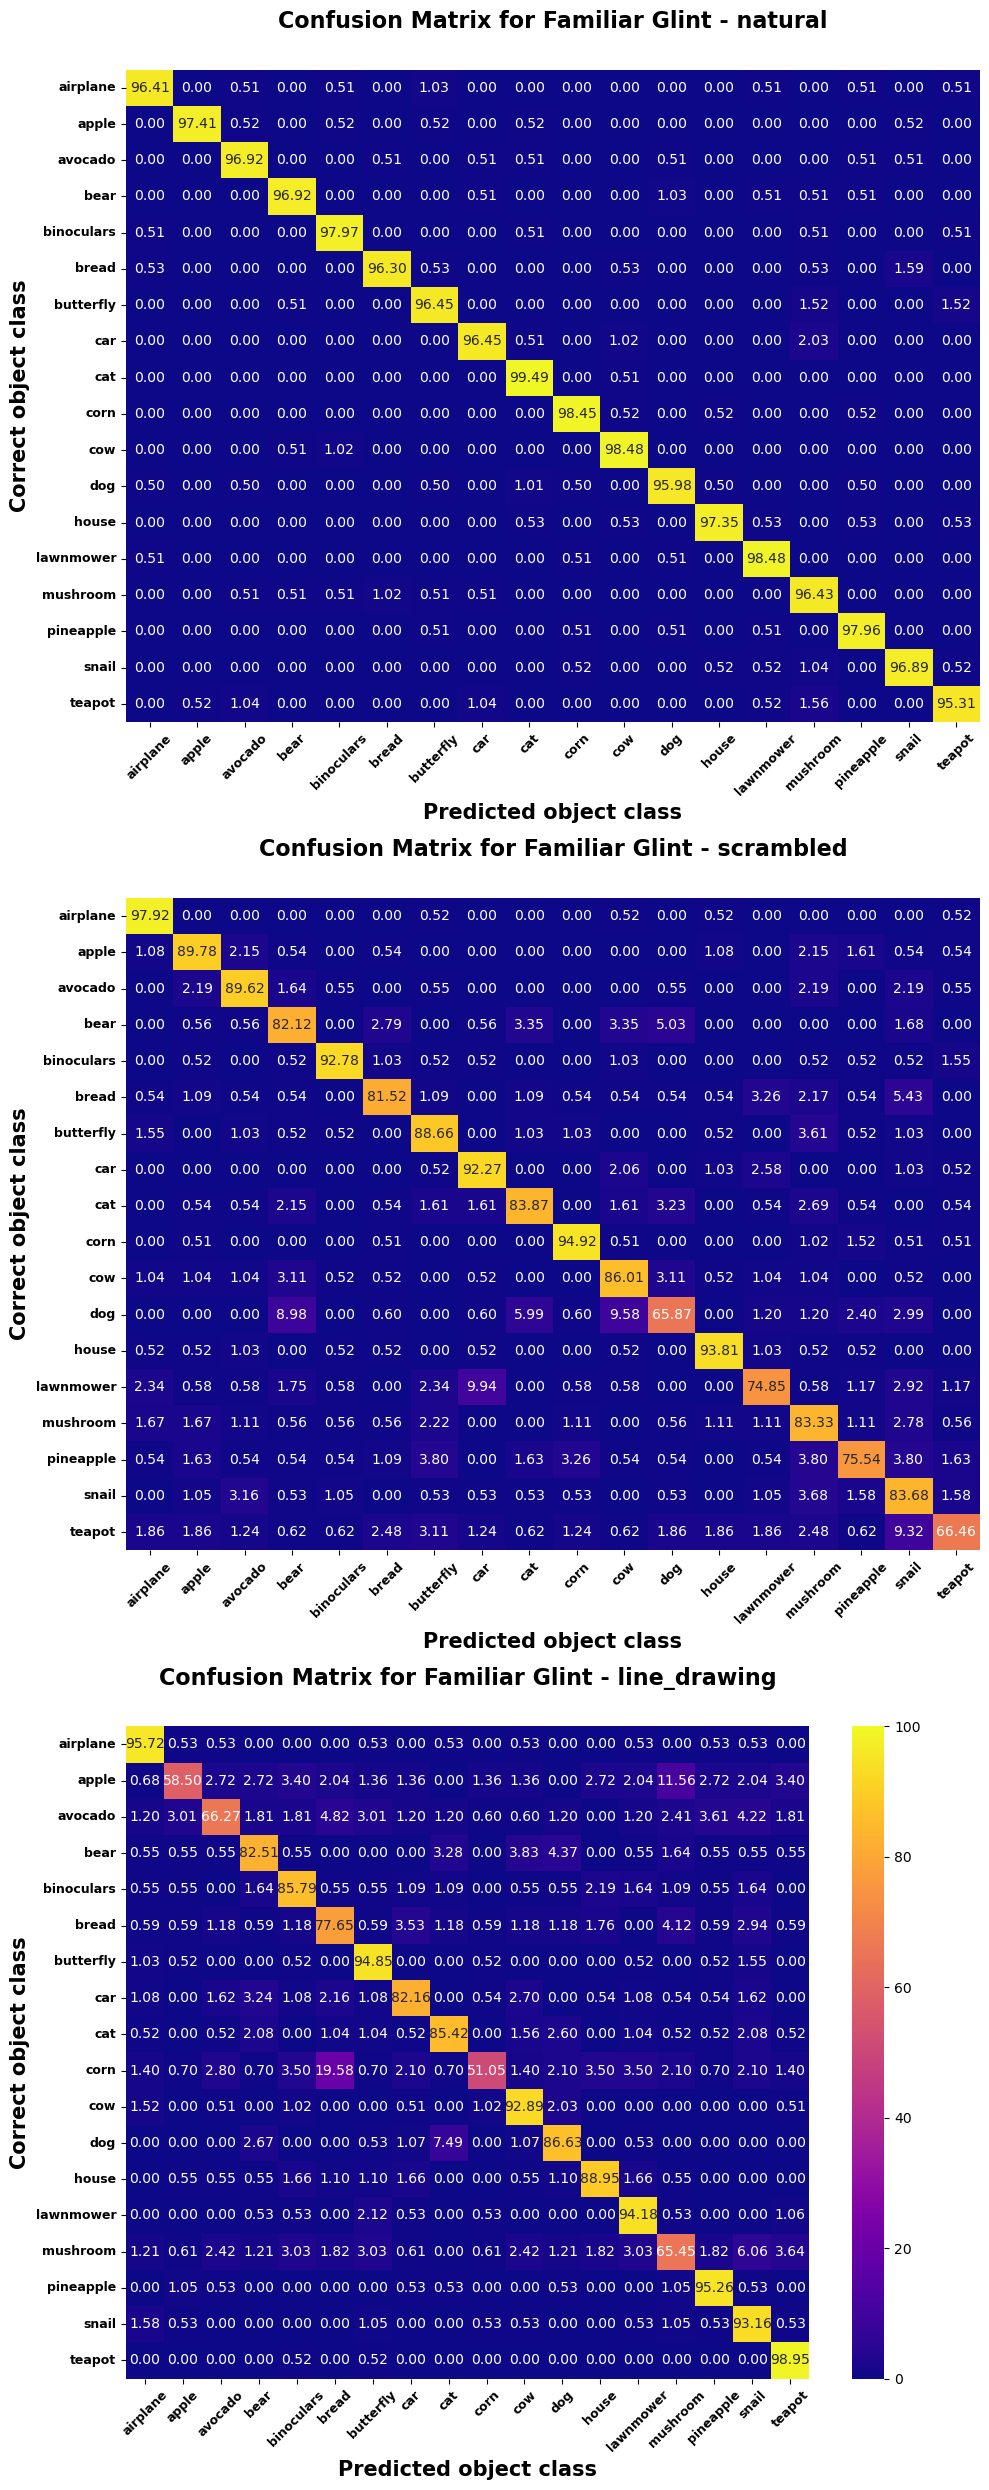

Experiment: Novel, Condition: natural
natural
prediction       krar  sarangi  sistrum  sheng
obj_true_class                                
krar            72.04     8.82     8.82  10.32
sarangi         15.88    67.60     4.94  11.59
sistrum         13.45     7.56    69.96   9.03
sheng            5.51    10.81    11.86  71.82
Row sums:
obj_true_class
krar       100.0
sarangi    100.0
sistrum    100.0
sheng      100.0
dtype: float64

Experiment: Novel, Condition: scrambled
scrambled
prediction       krar  sarangi  sistrum  sheng
obj_true_class                                
krar            34.38    20.00    24.79  20.83
sarangi         16.10    44.92    17.80  21.19
sistrum         17.72    14.56    50.63  17.09
sheng           12.18    15.76    12.61  59.45
Row sums:
obj_true_class
krar       100.0
sarangi    100.0
sistrum    100.0
sheng      100.0
dtype: float64

Experiment: Novel, Condition: line_drawing
line_drawing
prediction       krar  sarangi  sistrum  sheng
obj_true_class     

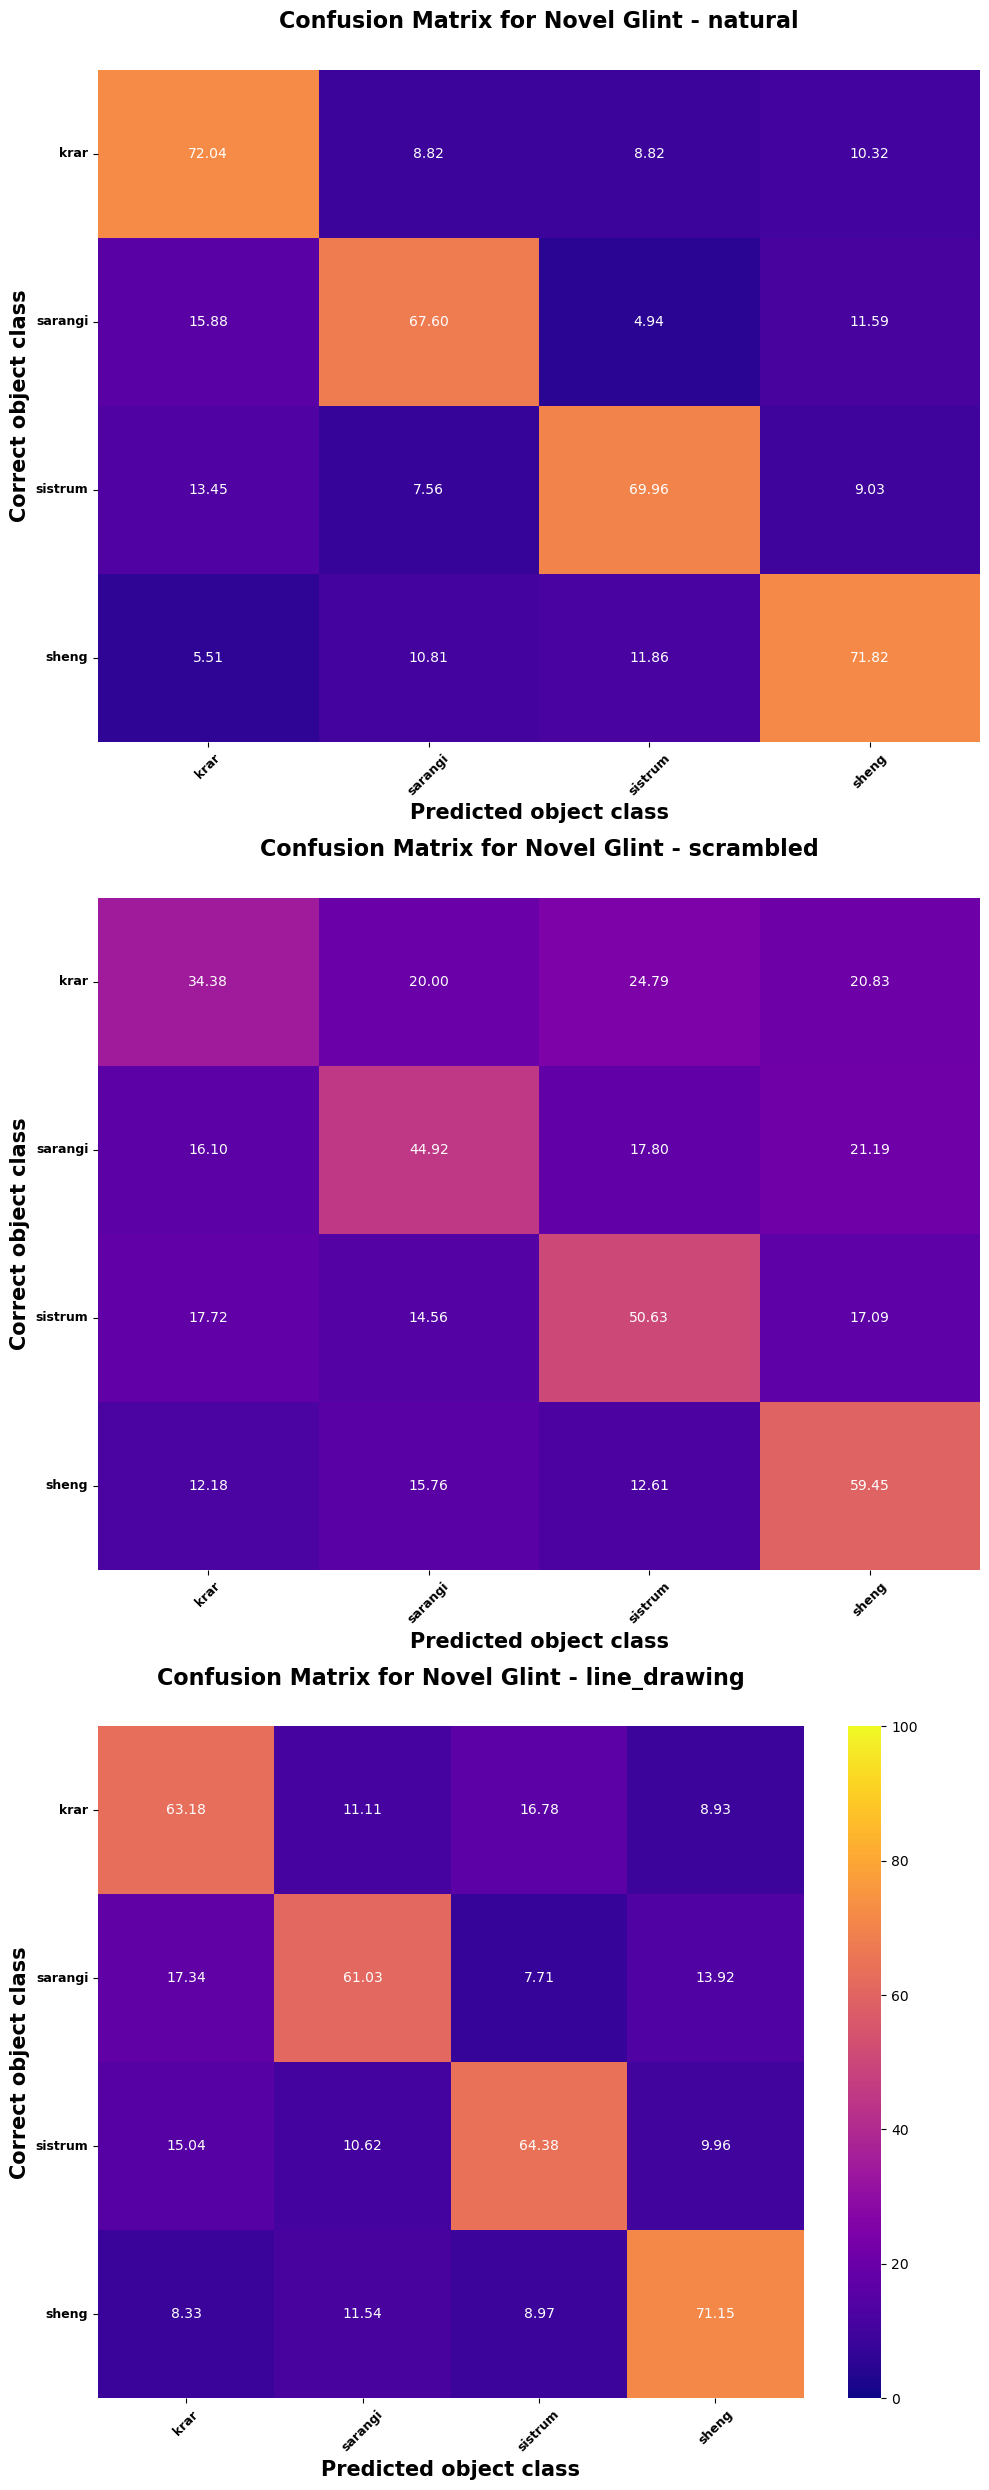

In [3]:
'''This function takes the summary dataframes we created for each experiment and produces confusion matrices for each condition within each experiment.

'''


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def create_confusion_matrices(familiar_sub_summary, novel_sub_summary, experiments):
    for experiment in experiments:
        if experiment == 'familiar':
            object_classes = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
        elif experiment == 'novel':
            object_classes = ['krar', 'sarangi', 'sistrum', 'sheng']

        conditions = ['natural', 'scrambled', 'line_drawing']

        for condition_name in conditions:
            if experiment == 'familiar':
                sub_summary = familiar_sub_summary
            elif experiment == 'novel':
                sub_summary = novel_sub_summary

            condition_data = sub_summary[sub_summary['condition_block'] == condition_name]

            counts = pd.crosstab(
                condition_data['obj_true_class'],
                condition_data['prediction']
            )

            counts = counts.reindex(index=object_classes, columns=object_classes, fill_value=0)

            row_totals = counts.sum(axis=1)
            response_percent = counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0) * 100

            # Create the confusion matrices for each condition, and do this for both experiments (familiar and novel)
            if experiment == 'familiar': # Familiar experiment
                if condition_name == 'natural':
                    fam_confusion_matrix_natural = response_percent
                
                elif condition_name == 'scrambled':
                    fam_confusion_matrix_scrambled = response_percent

                elif condition_name == 'line_drawing':
                    fam_confusion_matrix_line_drawing = response_percent
            elif experiment == 'novel': # Novel Experiment
                if condition_name == 'natural':
                    novel_confusion_matrix_natural = response_percent
                
                elif condition_name == 'scrambled':
                    novel_confusion_matrix_scrambled = response_percent.round(2)

                elif condition_name == 'line_drawing':
                    novel_confusion_matrix_line_drawing = response_percent.round(2)

            print(f"Experiment: {experiment.capitalize()}, Condition: {condition_name}")
            print(condition_name)
            print(response_percent.round(2))
            print("Row sums:")
            print(response_percent.sum(axis=1).round(2))
            print()

        # Plot each confusion matrix to visualize the patterns of responses for each condition
        fig, axes = plt.subplots(3, 1, figsize=(10, 25), sharey=True)

        for ax, condition_name in zip(axes, conditions):
            condition_data = sub_summary[sub_summary['condition_block'] == condition_name]

            counts = pd.crosstab(
                condition_data['obj_true_class'],
                condition_data['prediction']
            )

            counts = counts.reindex(index=object_classes, columns=object_classes, fill_value=0)

            response_percent = counts.div(counts.sum(axis=1), axis=0).fillna(0) * 100

            sns.heatmap(
                response_percent,
                ax=ax,
                cmap='plasma', # could also use 'viridis', 'plasma', 'magma', or 'cividis' for better perceptual uniformity
                vmin=0,
                vmax=100,
                annot=True,
                fmt='.2f',
                annot_kws={'fontsize':10},
                cbar=ax is axes[-1]
                
            )

            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9, fontweight='bold')  # Rotate y-axis labels to horizontal
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, fontsize=9, fontweight='bold')  # Rotate x-axis labels for better readability
            ax.set_title(f'Confusion Matrix for {experiment.capitalize()} Glint - {condition_name}', fontsize=16, fontweight='bold', pad=30)
            ax.set_xlabel('Predicted object class', fontsize=15, fontweight='bold')
            ax.set_ylabel('Correct object class', fontsize=15, fontweight='bold') 


        plt.tight_layout()
        plt.show()

    return fam_confusion_matrix_natural, fam_confusion_matrix_scrambled, fam_confusion_matrix_line_drawing, novel_confusion_matrix_natural, novel_confusion_matrix_scrambled, novel_confusion_matrix_line_drawing

fam_confusion_matrix_natural, fam_confusion_matrix_scrambled, fam_confusion_matrix_line_drawing, novel_confusion_matrix_natural, novel_confusion_matrix_scrambled, novel_confusion_matrix_line_drawing = create_confusion_matrices(familiar_sub_summary, novel_sub_summary, experiments)

## Here is where the fun begins.... i.e., actual RSA calculation and creation

Now that we have all the data in a format compatible for RSA, we can actually carry out the RSA we need. Remeber, the questions we were asking? 

1. How does the response pattern of natural condition compare to both conditions in humans and models? 

2. How does the response patterns for each condition for humans compare to that of models?

What were the predictions?
1. We predict for familiar glint, the response pattern between natural and feature condition will exhibit higher degree of similarity, while shape and natural will exhibit a higher degree of dissimilarity.
1B. We predict for novel glint, the response pattern between natural and shape will exhibit a higher degree of similarity, while feature and natural will exhibit a higher degree of dissimilarity. 

2.  For both familiar and novel glint, models and humans will exhibit more similarity on the feature, and obviously natural, but display a high degree of dissimilarity on shape condition.

Remember this as we continue!!

### Step 1. Import packages and reset the index and rename the index

We will be using the rsatoolbox which comes equipped with functions for calculating the RDMs for each condition, comparing the RDM between conditions, comparing the RDMs between model and human, and ways to visualize RDMs. 

First step is final fine-tuning of dataset to abide by rsatoolbox dataset structure. Essentially we will strip the dataframe of column and row headers, collect the true_object_classes and prediction_classes to use for descriptors, and then we can actually make the rsatoolbox specific dataframe. 

I created a function to do all this and make my life easier, which will do all of the above and return 6 confusion matrices just the way rsatoolbox likes (3 for all three conditions of familiar and 3 for all three conditions of novel). 

In [28]:
import rsatoolbox, numpy
def convert_and_prep_data_for_rsa(fam_confusion_matrix_natural, fam_confusion_matrix_scrambled, fam_confusion_matrix_line_drawing, novel_confusion_matrix_natural, novel_confusion_matrix_scrambled, novel_confusion_matrix_line_drawing):
    # convert the confusion matrices to numpy arrays for use with rsatoolbox
    fam_natural_matrix_array = fam_confusion_matrix_natural.values
    fam_scrambled_matrix_array = fam_confusion_matrix_scrambled.values
    fam_line_drawing_matrix_array = fam_confusion_matrix_line_drawing.values

    # novel experiment confusion matrices
    novel_natural_matrix_array = novel_confusion_matrix_natural.values
    novel_scrambled_matrix_array = novel_confusion_matrix_scrambled.values
    novel_line_drawing_matrix_array = novel_confusion_matrix_line_drawing.values

    # Extract the object classes from the confusion matrices
    fam_object_classes = fam_confusion_matrix_natural.index.tolist()
    novel_object_classes = novel_confusion_matrix_natural.index.tolist()

    #Extract the prediction classes from the confusion matrices
    fam_prediction_classes = fam_confusion_matrix_natural.columns.tolist()
    novel_prediction_classes = novel_confusion_matrix_natural.columns.tolist()
    print(f"Familiar object classes: {fam_object_classes}")
    print(f"Novel object classes: {novel_object_classes}")
    print(f"Familiar prediction classes: {fam_prediction_classes}")
    print(f"Novel prediction classes: {novel_prediction_classes}")

    # now we can use these numpy arrays and class lists to create RDMs using rsatoolbox for further analysis.
    #familiar experiment RDMs
    fam_natural_rdm = rsatoolbox.data.Dataset(measurements=fam_natural_matrix_array, channel_descriptors={'prediction': fam_prediction_classes}, obs_descriptors = {'true_obj_class': fam_object_classes})
    fam_scrambled_rdm = rsatoolbox.data.Dataset(measurements=fam_scrambled_matrix_array, channel_descriptors={'prediction': fam_prediction_classes}, obs_descriptors = {'true_obj_class': fam_object_classes})
    fam_line_drawing_rdm = rsatoolbox.data.Dataset(measurements=fam_line_drawing_matrix_array, channel_descriptors={'prediction': fam_prediction_classes}, obs_descriptors = {'true_obj_class': fam_object_classes})

    #Novel experiment RDMs
    novel_natural_rdm = rsatoolbox.data.Dataset(measurements=novel_natural_matrix_array, channel_descriptors={'prediction': novel_prediction_classes}, obs_descriptors={'true_obj_class': novel_object_classes})
    novel_scrambled_rdm = rsatoolbox.data.Dataset(measurements=novel_scrambled_matrix_array, channel_descriptors={'prediction': novel_prediction_classes}, obs_descriptors={'true_obj_class': novel_object_classes})
    novel_line_drawing_rdm = rsatoolbox.data.Dataset(measurements=novel_line_drawing_matrix_array, channel_descriptors={'prediction': novel_prediction_classes}, obs_descriptors={'true_obj_class': novel_object_classes})

    return fam_natural_rdm, fam_scrambled_rdm, fam_line_drawing_rdm, novel_natural_rdm, novel_scrambled_rdm, novel_line_drawing_rdm

fam_natural_rdm, fam_scrambled_rdm, fam_line_drawing_rdm, novel_natural_rdm, novel_scrambled_rdm, novel_line_drawing_rdm = convert_and_prep_data_for_rsa(fam_confusion_matrix_natural, fam_confusion_matrix_scrambled, fam_confusion_matrix_line_drawing, novel_confusion_matrix_natural, novel_confusion_matrix_scrambled, novel_confusion_matrix_line_drawing)

print("Familiar Natural RDM:")
print(fam_natural_rdm)
print("Familiar Scrambled RDM:")
print(fam_scrambled_rdm)
print("Familiar Line Drawing RDM:")
print(fam_line_drawing_rdm)
print("Novel Natural RDM:")
print(novel_natural_rdm)
print("Novel Scrambled RDM:")
print(novel_scrambled_rdm)
print("Novel Line Drawing RDM:")
print(novel_line_drawing_rdm)   


Familiar object classes: ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
Novel object classes: ['krar', 'sarangi', 'sistrum', 'sheng']
Familiar prediction classes: ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
Novel prediction classes: ['krar', 'sarangi', 'sistrum', 'sheng']
Familiar Natural RDM:
rsatoolbox.data.Dataset
measurements = 
[[96.41025641  0.          0.51282051  0.          0.51282051  0.
   1.02564103  0.          0.          0.          0.          0.
   0.          0.51282051  0.          0.51282051  0.          0.51282051]
 [ 0.         97.40932642  0.51813472  0.          0.51813472  0.
   0.51813472  0.          0.51813472  0.          0.          0.
   0.          0.          0.          0.          0.518134

### Create the RDMs for each condition of Familiar and Novel Glint


Now that we have confusion matrices for each experiment and subsequent condition, we can calculate the rdm which will carry out pairwise distance calculations. For example, one pairwise distance calculation will be comparing the prediction of cat when true object class is cat vs the prediction of teapot when true object class is cat. You can always change the way in which we estimate dissimilarities by changing the method attribute within the calc_rdm function. Since we are using euclidian, the default by rsatoolbox is to use the squared version, but this will exaggerate differences between conditions, our scale of measurement is meaningful (i.e, proportion of each response for an object class, e.g., amount of times they predicted the previously seen object was a dog when they true object class they saw was a cat), and I want to keep the distances proportional to our actual data. 

rsatoolbox.rdm.RDMs
1 RDM(s) over 18 conditions

dissimilarity_measure = 
euclidean

dissimilarities[0] = 
[[ 0.         32.30505457 32.13947979 32.22528268 32.22963253 32.03367467
  31.97634972 32.14954774 32.65671354 32.48135004 32.48529755 31.98351518
  32.29634852 32.31524176 32.14206609 32.31125233 32.21998371 31.87438206]
 [32.30505457  0.         32.30417816 32.39179072 32.47814    32.28720251
  32.22907265 32.31508963 32.73276542 32.64610686 32.64957548 32.23395599
  32.46251581 32.6500321  32.3085345  32.56312961 32.30029631 32.03903733]
 [32.13947979 32.30417816  0.         32.30904895 32.48435708 32.12119698
  32.23397324 32.14861115 32.65357712 32.56535493 32.57018032 31.98344173
  32.38129888 32.56929677 32.14204753 32.39659568 32.2200213  31.8697837 ]
 [32.22528268 32.39179072 32.30904895  0.         32.48480684 32.20788382
  32.14817048 32.14771606 32.74071473 32.56580357 32.48660112 31.98389853
  32.38175007 32.48304411 32.05782397 32.39614929 32.30466358 32.04390073]
 

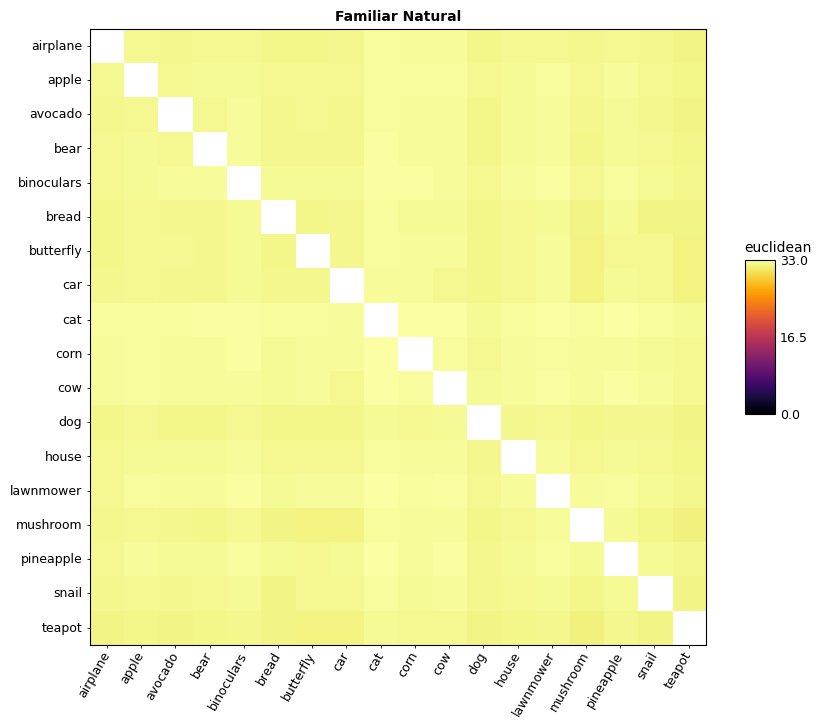

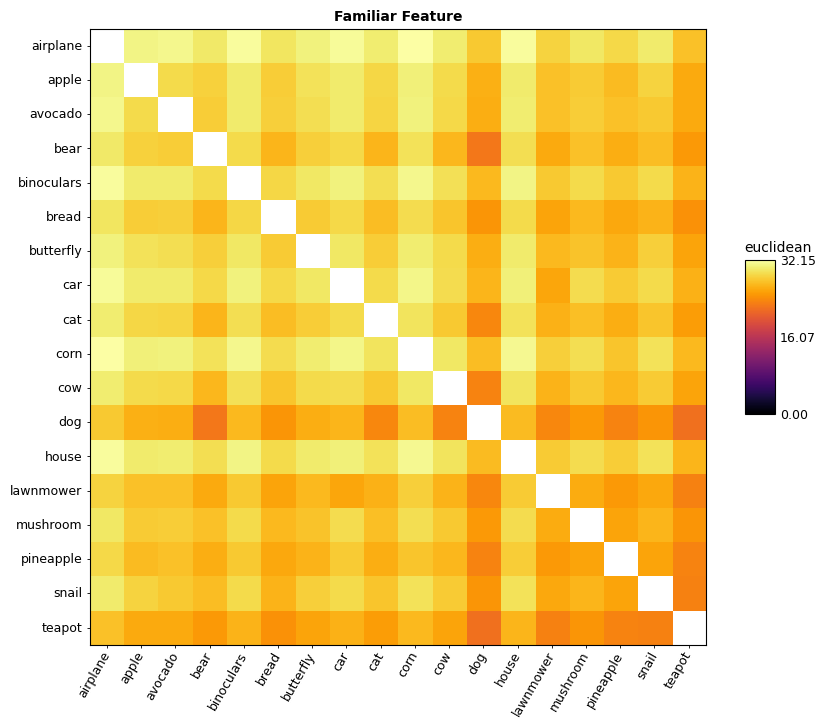

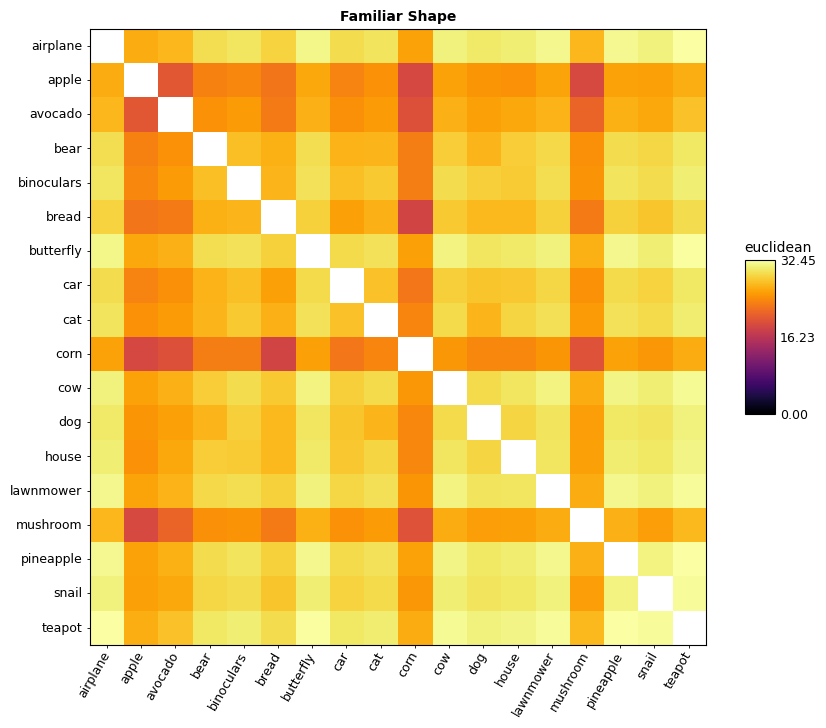

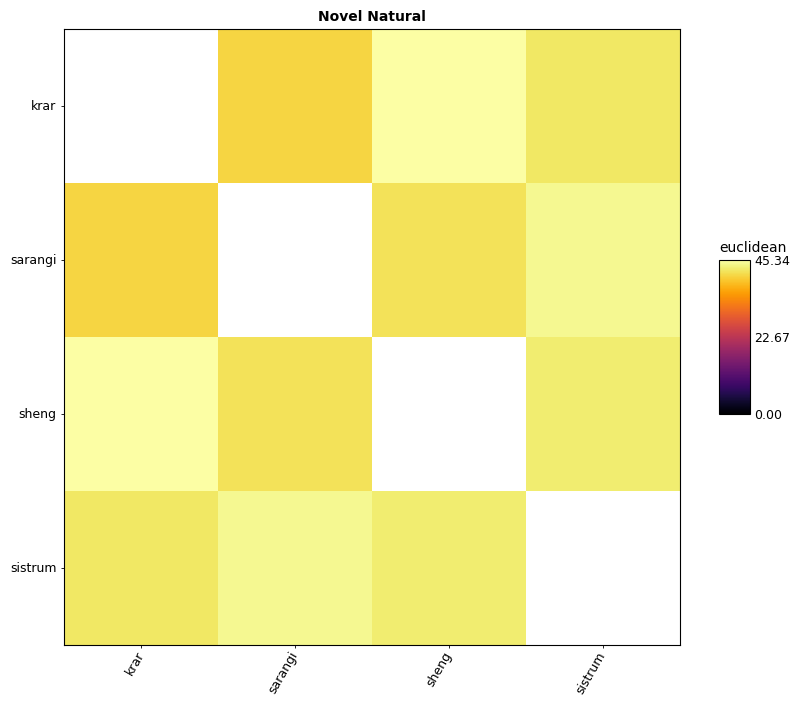

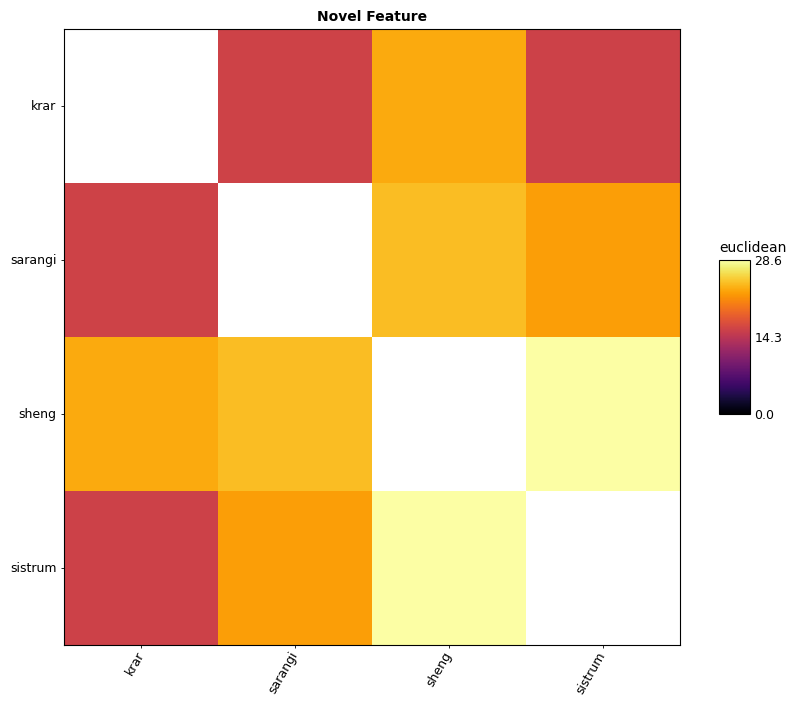

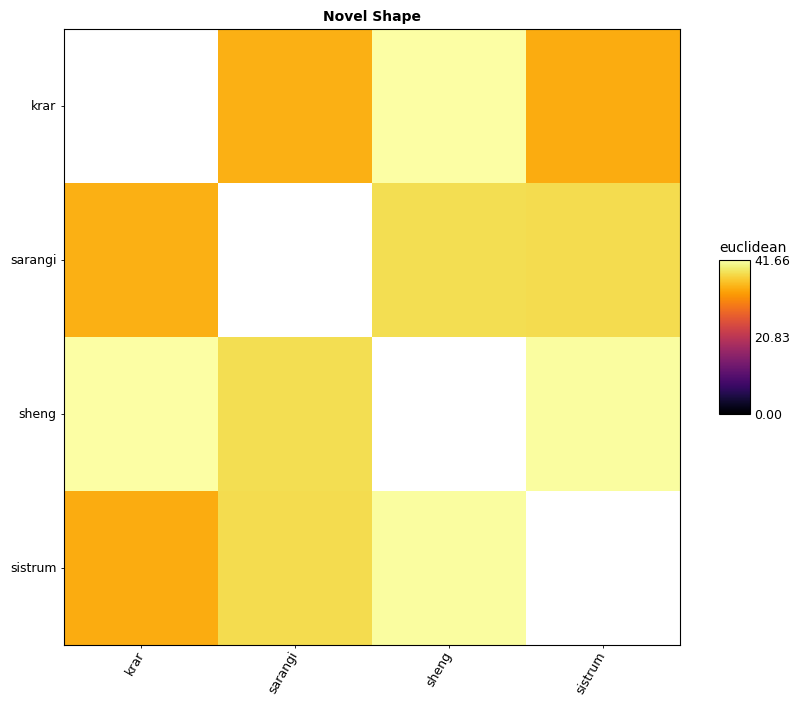

In [ ]:
#--------------------------------------------------------------- Familiar Experiment RDMs --------------------------------------------------------------

# Now that we have the RDMs for each condition in both experiments, we can proceed to analyze them further using rsatoolbox. This may include comparing the RDMs across conditions, calculating similarity metrics, or visualizing the RDMs in various ways.
# first lets estimate the dissimilarity between the RDMs for each condition in both experiments using the correlation distance metric. This will give us a measure of how similar or dissimilar the response patterns are across conditions and experiments.   

#Extract the object and prediction classes from the confusion matrices
fam_prediction_classes = fam_confusion_matrix_natural.columns.tolist()
fam_object_classes = fam_confusion_matrix_natural.index.tolist()

# now calculate the dissimilarity between the RDMs for each condition in both experiments using the correlation distance metric.
# Natural
fam_rdm_natural = rsatoolbox.rdm.calc_rdm(fam_natural_rdm, method='euclidean', descriptor='true_obj_class')
fam_rdm_natural_nonsquared = rsatoolbox.rdm.sqrt_transform(fam_rdm_natural)

# Feature
fam_rdm_feature = rsatoolbox.rdm.calc_rdm(fam_scrambled_rdm, method='euclidean', descriptor='true_obj_class')
fam_rdm_feature_nonsquared = rsatoolbox.rdm.sqrt_transform(fam_rdm_feature)

# Shape
fam_rdm_shape = rsatoolbox.rdm.calc_rdm(fam_line_drawing_rdm, method='euclidean', descriptor='true_obj_class')
fam_rdm_shape_nonsquared = rsatoolbox.rdm.sqrt_transform(fam_rdm_shape)

print(fam_rdm_natural_nonsquared)
print(fam_rdm_feature_nonsquared)
print(fam_rdm_shape_nonsquared)


# Visualize the RDMs for each condition in the familiar experiment using rsatoolbox's visualization functions. This will allow us to see the dissimilarity patterns across conditions and how they relate to the object classes.
print("Dissimilarity RDM for Familiar Natural Condition:")
fam_nat_vmax = fam_rdm_natural_nonsquared.dissimilarities.max()
fig, ax, ret_val = rsatoolbox.vis.show_rdm(fam_rdm_natural_nonsquared, rdm_descriptor='Familiar Natural', figsize= (10, 8), pattern_descriptor='true_obj_class', show_colorbar='panel', vmin=0, vmax=fam_nat_vmax,cmap='inferno')

print("Dissimilarity RDM for Familiar Feature Condition:")
fam_feat_vmax = fam_rdm_feature_nonsquared.dissimilarities.max()
fig, ax, ret_val = rsatoolbox.vis.show_rdm(fam_rdm_feature_nonsquared, rdm_descriptor='Familiar Feature', figsize= (10, 8), pattern_descriptor='true_obj_class', show_colorbar='panel', vmin=0, vmax=fam_feat_vmax, cmap='inferno')

print("Dissimilarity RDM for Familiar Shape Condition:")
fam_shape_vmax = fam_rdm_shape_nonsquared.dissimilarities.max()
fig, ax, ret_val = rsatoolbox.vis.show_rdm(fam_rdm_shape_nonsquared, rdm_descriptor='Familiar Shape', figsize= (10, 8), pattern_descriptor='true_obj_class', show_colorbar='panel', vmin=0, vmax=fam_shape_vmax, cmap='inferno')

#--------------------------------------------------------------Novel Experiment RDMs--------------------------------------------------------------
# Now that we have the RDMs for each condition in both experiments, we can proceed to analyze them further using rsatoolbox. This may include comparing the RDMs across conditions, calculating similarity metrics, or visualizing the RDMs in various ways.
# first lets estimate the dissimilarity between the RDMs for each condition in both experiments using the correlation distance metric. This will give us a measure of how similar or dissimilar the response patterns are across conditions and experiments.   

#Extract the object and prediction classes from the confusion matrices
novel_prediction_classes = novel_confusion_matrix_natural.columns.tolist()
novel_object_classes = novel_confusion_matrix_natural.index.tolist()

# now calculate the dissimilarity between the RDMs for each condition in both experiments using the correlation distance metric.
# Natural
novel_rdm_natural = rsatoolbox.rdm.calc_rdm(novel_natural_rdm, method='euclidean', descriptor='true_obj_class')
novel_rdm_natural_nonsquared = rsatoolbox.rdm.sqrt_transform(novel_rdm_natural)

# Feature
novel_rdm_feature = rsatoolbox.rdm.calc_rdm(novel_scrambled_rdm, method='euclidean', descriptor='true_obj_class')
novel_rdm_feature_nonsquared = rsatoolbox.rdm.sqrt_transform(novel_rdm_feature)

# Shape
novel_rdm_shape = rsatoolbox.rdm.calc_rdm(novel_line_drawing_rdm, method='euclidean', descriptor='true_obj_class')
novel_rdm_shape_nonsquared = rsatoolbox.rdm.sqrt_transform(novel_rdm_shape)



print(novel_rdm_natural_nonsquared)
print(novel_rdm_feature_nonsquared)
print(novel_rdm_shape_nonsquared)

# Visualize the RDMs for each condition in the novel experiment using rsatoolbox's visualization functions. This will allow us to see the dissimilarity patterns across conditions and how they relate to the object classes.
print("Dissimilarity RDM for Novel Natural Condition:")
fam_nat_vmax = novel_rdm_natural_nonsquared.dissimilarities.max()
fig, ax, ret_val = rsatoolbox.vis.show_rdm(novel_rdm_natural_nonsquared, rdm_descriptor='Novel Natural', figsize= (10, 8), pattern_descriptor='true_obj_class', show_colorbar='panel', vmin=0, vmax=fam_nat_vmax,cmap='inferno')

print("Dissimilarity RDM for Novel Feature Condition:")
fam_feat_vmax = novel_rdm_feature_nonsquared.dissimilarities.max()
fig, ax, ret_val = rsatoolbox.vis.show_rdm(novel_rdm_feature_nonsquared, rdm_descriptor='Novel Feature', figsize= (10, 8), pattern_descriptor='true_obj_class', show_colorbar='panel', vmin=0, vmax=fam_feat_vmax, cmap='inferno')

print("Dissimilarity RDM for Novel Shape Condition:")
fam_shape_vmax = novel_rdm_shape_nonsquared.dissimilarities.max()
fig, ax, ret_val = rsatoolbox.vis.show_rdm(novel_rdm_shape_nonsquared, rdm_descriptor='Novel Shape', figsize= (10, 8), pattern_descriptor='true_obj_class', show_colorbar='panel', vmin=0, vmax=fam_shape_vmax, cmap='inferno')

Now that the RDMS are made we can compare RDMs. These comparisons I have below are in line with my first set of questions and predictions I am asking. 

In [50]:
#------------------------------------------------------------Familiar Experiment RDM Comparisons--------------------------------------------------------------
fam_natural_vs_feature = rsatoolbox.rdm.compare(fam_rdm_natural_nonsquared, fam_rdm_feature_nonsquared, method='corr')

print("Correlation distance between Familiar Natural and Familiar Feature RDMs:")
print(fam_natural_vs_feature)

fam_natural_vs_shape = rsatoolbox.rdm.compare(fam_rdm_natural_nonsquared, fam_rdm_shape_nonsquared, method='corr')
print("Correlation distance between Familiar Natural and Familiar Shape RDMs:")
print(fam_natural_vs_shape)

fam_shape_vs_feature = rsatoolbox.rdm.compare(fam_rdm_shape_nonsquared, fam_rdm_feature_nonsquared, method='corr')
print("Correlation distance between Familiar Shape and Familiar Feature RDMs:")
print(fam_shape_vs_feature)

#------------------------------------------------------------Novel Experiment RDM Comparisons--------------------------------------------------------------
novel_natural_vs_feature = rsatoolbox.rdm.compare(novel_rdm_natural_nonsquared, novel_rdm_feature_nonsquared, method='corr')

print("Correlation distance between Novel Natural and Novel Feature RDMs:")
print(novel_natural_vs_feature)

novel_natural_vs_shape = rsatoolbox.rdm.compare(novel_rdm_natural_nonsquared, novel_rdm_shape_nonsquared, method='corr')
print("Correlation distance between Novel Natural and Novel Shape RDMs:")
print(novel_natural_vs_shape)

novel_shape_vs_feature = rsatoolbox.rdm.compare(novel_rdm_shape_nonsquared, novel_rdm_feature_nonsquared, method='corr')
print("Correlation distance between Novel Shape and Novel Feature RDMs:")
print(novel_shape_vs_feature)


Correlation distance between Familiar Natural and Familiar Feature RDMs:
[[0.25741458]]
Correlation distance between Familiar Natural and Familiar Shape RDMs:
[[-0.10109139]]
Correlation distance between Familiar Shape and Familiar Feature RDMs:
[[-0.32692096]]
Correlation distance between Novel Natural and Novel Feature RDMs:
[[0.44325837]]
Correlation distance between Novel Natural and Novel Shape RDMs:
[[0.69629396]]
Correlation distance between Novel Shape and Novel Feature RDMs:
[[0.89889804]]


## Child confusion Matrix (under construction!!!)

In [ ]:
import glob
import pandas as pd

experiment = 'familiar' # set experiment variable to either 'familiar' or 'novel', this will determine which data files we pull and how we structure the summary dataframes


# Define the paths 
base = '/zpool/vladlab/data_drive/glint_master/data/child_data'
    
core_path = f'{base}/{experiment}_glint' # set core path using experiment variable and base path

# participants we excluded in our original analysis
excluded_participants = []

# List of object classes in the experiment, which we will loop through to create summary dataframes for each object class
objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']

# Initialize empty dataframe
participant_summary_df = pd.DataFrame()

sub_summary = pd.DataFrame()

base = '/zpool/vladlab/data_drive/glint_master/data/child_data'
    
# import the files
files = glob.glob(f'{core_path}/*.csv') 
print(f"You have selected {experiment} glint experiment")


    
for obj in objects:
    for file in files:

        # Take the data for one participant at a time
        data = pd.read_csv(file)

        # Check if the participant is in the excluded list
        if data.loc[0, 'participant'] in excluded_participants:
            continue # skip this participant if they are in the excluded list
        

        '''        
        We apply the exclusion criteria to the data for each participant before we create the summary dataframes.
        Exclusion criteria 1: Remove No responses
        Exclusion criteria 2: Remove RTs less than or equal to 100ms
        Exclusion criteria 3: Remove RTs outside mean ± 2*SD
        
        '''
        # Exclusion criteria 1: Remove No responses
        data_exclusion_1 = data[data['response_label'] != 'no_response']

        # Exclusion criteria 2: Remove RTs less than or equal to 100ms
        data_exclusion_2 = data_exclusion_1[data_exclusion_1['key_resp.rt'] >= 0.1]

        # Exclusion criteria 3: Remove RTs outside mean ± 2*SD
        rt_mean = data_exclusion_2['key_resp.rt'].mean()
        rt_std = data_exclusion_2['key_resp.rt'].std()
        data_exclusion_3 = data_exclusion_2[(data_exclusion_2['key_resp.rt'] >= rt_mean - 2*rt_std) & (data_exclusion_2['key_resp.rt'] <= rt_mean + 2*rt_std)]



        # Filter for the current object class
        if experiment == 'familiar':
            object_trials = data_exclusion_3[data_exclusion_3['object_class'] == obj]
        
        
        # Extract only the columns you want
        if experiment == 'familiar':
            subset = object_trials[[
                'participant',
                'img_condition', # condition (natural, scrambled, line_drawing)
                'object_class', # The correct object class of the image they were shown (ex: airplane, car, etc.)
                'object_category', # The animacy category of the image they were shown (animate, inanimate natural, inanimate artificial)
                'response_label', # Response given by subject (ex: car, dog, cat, etc.)
                'response_animacy', # Animacy of the response they gave (animate, inanimate natural, inanimate artificial)
                'key_resp.corr', # Whether the response was correct (1) or incorrect (0)
                'key_resp.keys', # The actual key they pressed for their response
                #'object_class', # The object class of the image they were shown (ex: airplane, car, etc.)
                'prompt_1', # The first prompt they saw for that trial (ex: "Is this a car?")
                'prompt_2', 
                'prompt_3', 
                'prompt_4', 
                'prompt_5', 
                'prompt_6', 
                'prompt_7', 
                'prompt_8', 
                'prompt_9']].copy()
            
        if experiment == 'novel':
            subset = object_trials[[
                'participant',
                'response_label', 
                'key_resp.corr', 
                'key_resp.keys', 
                'img_condition', 
                'img_class',
                'prompt_1',
                'prompt_2',
                'prompt_3',
                'prompt_4']].copy()
            
        column_map = {
            "reponse_label": "response_by_subject",
            "key_resp.corr": "correct (0=incorrect, 1=correct)",
            "key_resp.keys": "keyboard_response",
            "img_condition": "condition_block",
            "object_category": "correct_animacy",
            "img_class": "correct_object_class",
            "object_class": "correct_object_class"}

        #rename the colimns to standardize across experiment versions
        data = subset.rename(columns=column_map)

        
        # Append to the summary list
        participant_summary_df = pd.concat([participant_summary_df, data], ignore_index=True) #append the subset dataframe for this object class and participant to the overall participant summary dataframe



    # Combine all into one dataframe
    sub_summary = pd.concat([sub_summary, participant_summary_df], ignore_index=True)


## Model Confusion Matrix

As most of the preprocessing is already done in my modeling script, we can just take the all_models_raw.csv file. Then we will just need to swap some of the variable names to match the names I had in the modelling script.

### Define the path and read in the data

In [4]:
familiar_path = '/zpool/vladlab/data_drive/glint_master/data/model_data/familiar/models_combined/adult_familiar_all_models_raw_v2.csv'

familiar_df = pd.read_csv(familiar_path)
print(familiar_df.head(1))
models = familiar_df['id'].unique()
print(models)


         id classifier experiment_label  number_of_train_imgs condition  \
0  convnext        KNN         familiar                   300   natural   

  test_obj       animacy    obj1      obj2   obj3  ...        obj5 obj6  obj7  \
0     bear  anim_natural  teapot  mushroom  bread  ...  binoculars  cow  bear   

        obj8       obj9  panel_seed  vote_method filtered_acc  pred_label  \
0  lawnmower  pineapple  1085006768      invdist          1.0        bear   

  adult_or_child  
0          adult  

[1 rows x 21 columns]
['convnext' 'vit']


### Generate the Confusion matrix

In [5]:
import pandas as pd
import numpy as np

fam_objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
conditions = ['natural', 'shape', 'feature']
models = ['convnext', 'vit']

for condition_name in conditions:
    for model in models:
            
        condition_data = familiar_df[(familiar_df['condition'] == condition_name) & (familiar_df['id'] == model)] # filter for the current condition and model predictions only
        counts = pd.crosstab(
            condition_data['test_obj'],
            condition_data['pred_label']
        )

        counts = counts.reindex(index=fam_objects, columns=fam_objects, fill_value=0)

        row_totals = counts.sum(axis=1)
        response_percent = counts.div(row_totals.replace(0, np.nan), axis=0).fillna(0) * 100

        if condition_name == 'natural':
            confusion_matrix = response_percent.round(1)
        
        elif condition_name == 'shape':
            confusion_matrix_scrambled = response_percent.round(1)

        elif condition_name == 'feature':
            confusion_matrix_line_drawing = response_percent.round(1)
        print(model)
        print(condition_name)
        print(response_percent.round(1))
        print("Row sums:")
        print(response_percent.sum(axis=1).round(1))
        print()

convnext
natural
pred_label  airplane  apple  avocado   bear  binoculars  bread  butterfly  \
test_obj                                                                    
airplane       100.0    0.0      0.0    0.0         0.0    0.0        0.0   
apple            0.0  100.0      0.0    0.0         0.0    0.0        0.0   
avocado          0.0    0.0    100.0    0.0         0.0    0.0        0.0   
bear             0.0    0.0      0.0  100.0         0.0    0.0        0.0   
binoculars       0.0    0.0      0.0    0.0       100.0    0.0        0.0   
bread            0.0    0.0      0.0    0.0         0.0  100.0        0.0   
butterfly        0.0    0.0      0.0    0.0         0.0    0.0      100.0   
car              0.0    0.0      0.0    0.0         0.0    0.0        0.0   
cat              0.0    0.0      0.0    0.0         0.0    0.0        0.0   
corn             0.0    0.0      0.0    0.0         0.0    0.0        0.0   
cow              0.0    0.0      0.0    0.0         0.0    

### Let's plot it as a figure

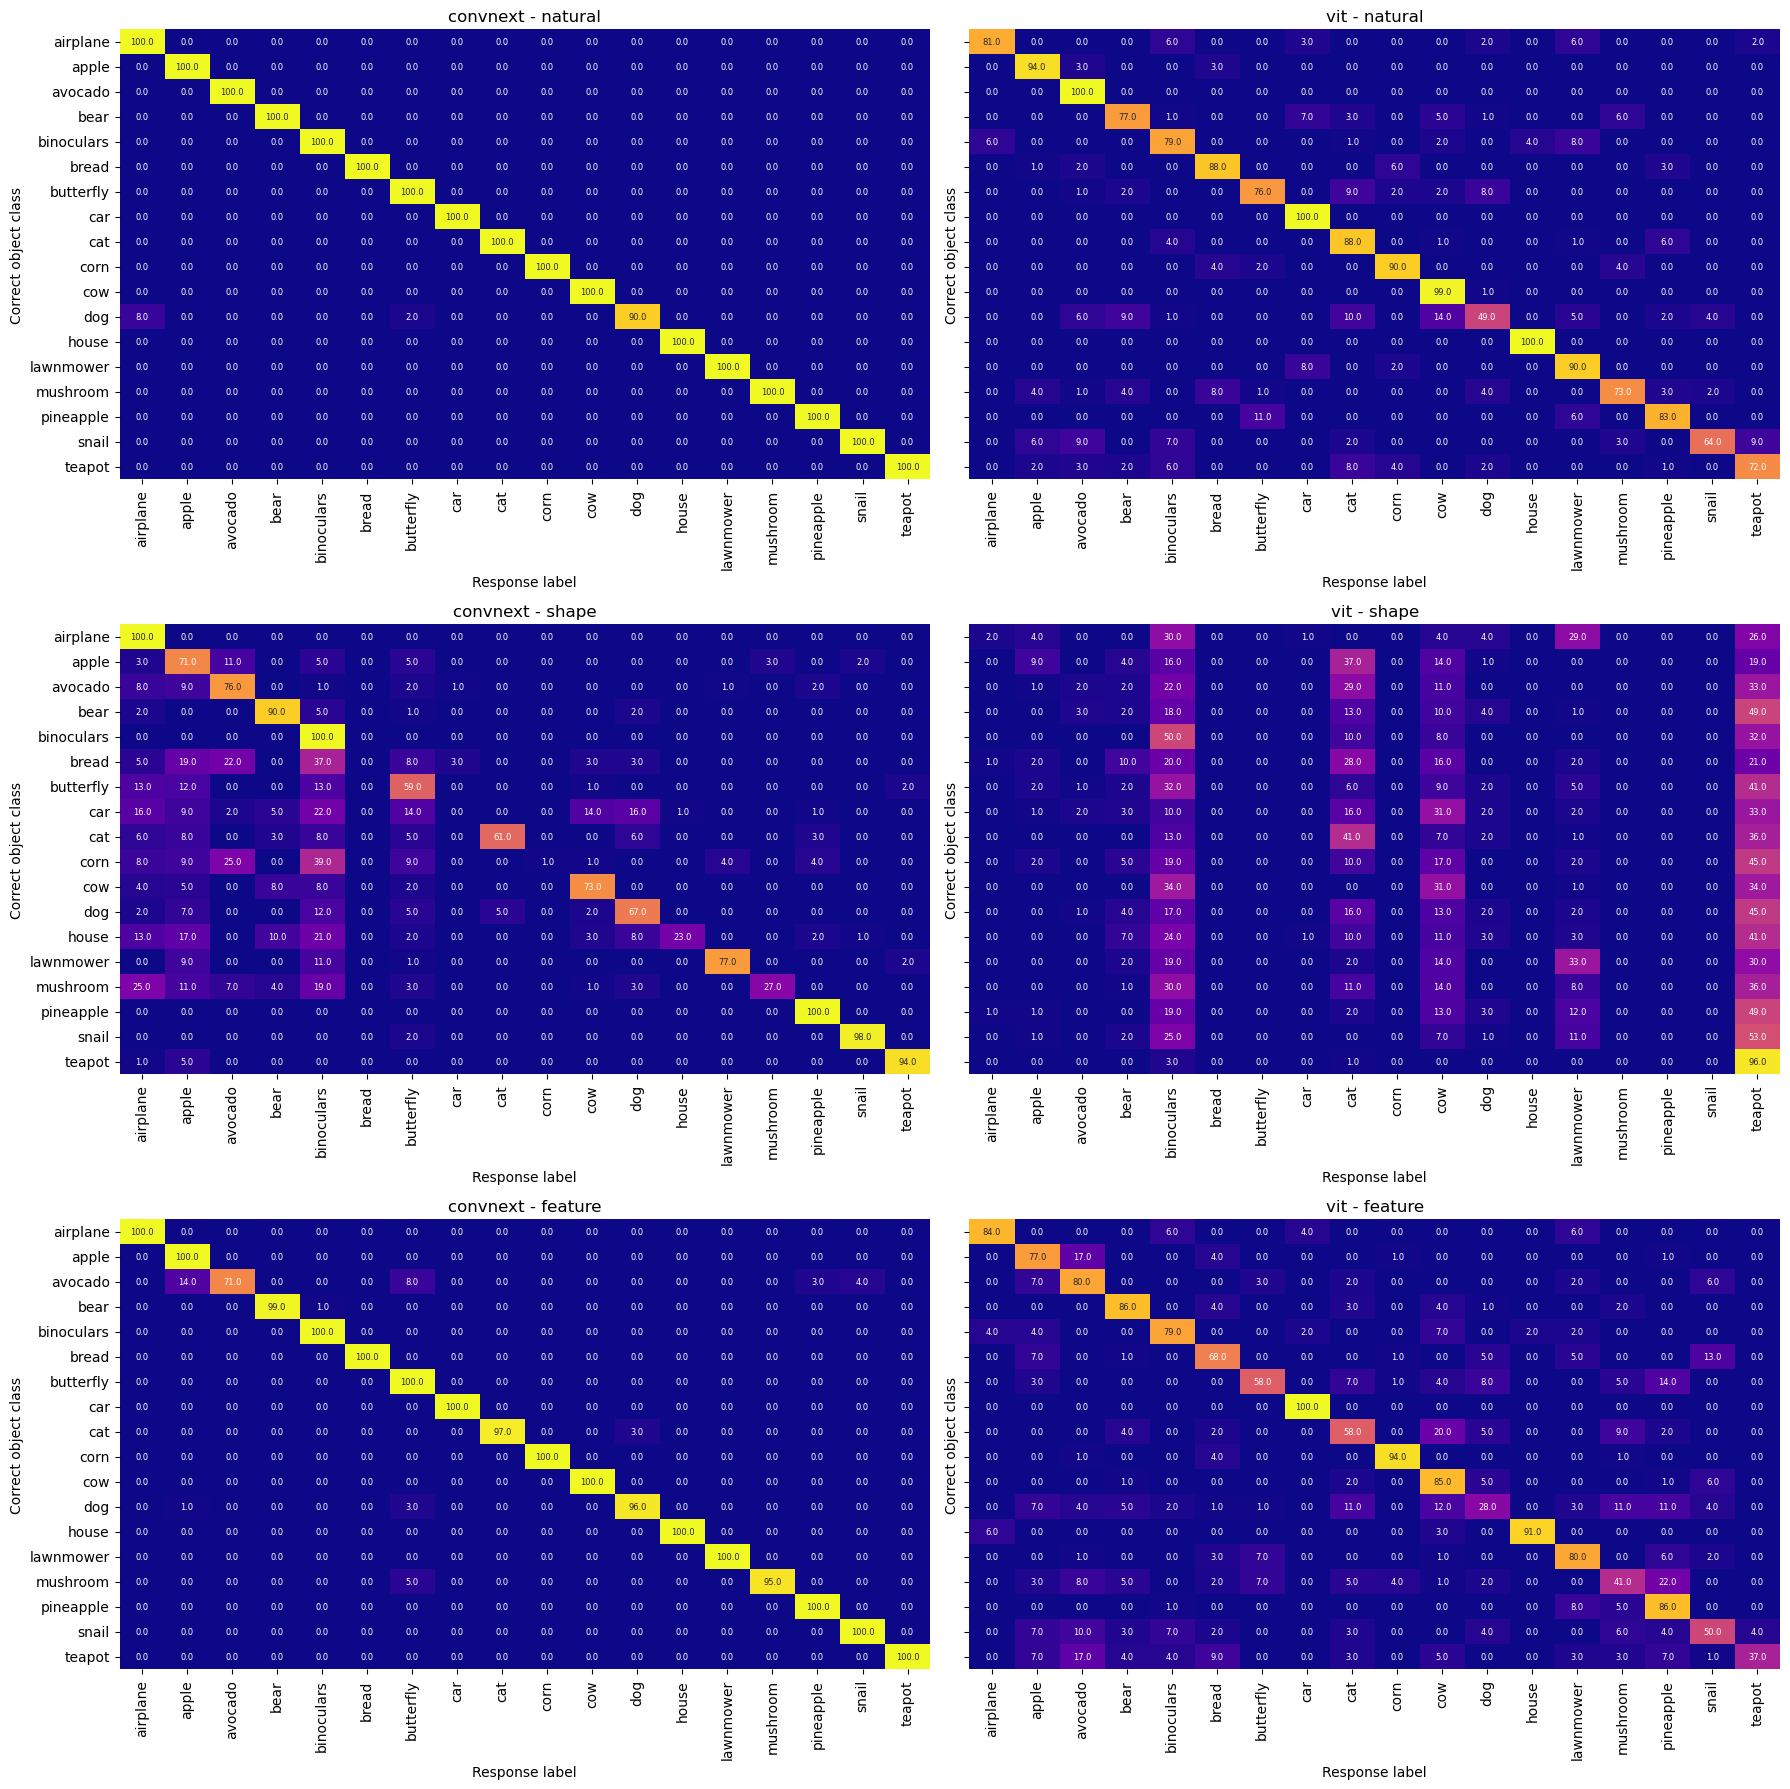

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

fam_objects = ['airplane', 'apple', 'avocado', 'bear', 'binoculars', 'bread', 'butterfly', 'car', 'cat', 'corn', 'cow', 'dog', 'house', 'lawnmower', 'mushroom', 'pineapple', 'snail', 'teapot']
conditions = ['natural', 'shape', 'feature']
models = ['convnext', 'vit']


fig, axes = plt.subplots(len(conditions), len(models), figsize=(18, 18), sharey=True)

for i, condition in enumerate(conditions):
    for j, model in enumerate(models):
        ax = axes[i, j]
        condition_data = familiar_df[(familiar_df['condition'] == condition) & (familiar_df['id'] == model)] # filter for the current condition and model predictions only
        counts = pd.crosstab(
            condition_data['test_obj'],
            condition_data['pred_label']
        )

        counts = counts.reindex(index=fam_objects, columns=fam_objects, fill_value=0)

        response_percent = counts.div(counts.sum(axis=1), axis=0).fillna(0) * 100

        sns.heatmap(
            response_percent,
            ax=ax,
            cmap='plasma', # could also use 'viridis', 'plasma', 'magma', or 'cividis' for better perceptual uniformity
            vmin=0,
            vmax=100,
            annot=True,
            fmt='.1f',
            annot_kws={'fontsize':6},
            cbar=ax is axes[-1]
            
        )

        ax.set_title(f'{model} - {condition}')
        ax.set_xlabel('Response label')
        ax.set_ylabel('Correct object class')

plt.tight_layout()
plt.show()